## 1. Introduction
In this mini-project, we implement and compare two sequence learning models, Simple Recurrent Neural Network **(Simple RNN)** and Long Short-Term Memory **(LSTM)**, for **text classification** tasks. The models are trained on the **20 Newsgroups dataset**, which contains news articles grouped into multiple topic categories.

The dataset is preprocessed using **tokenization**, **sequence padding**, and **one-hot encoding** to prepare it for training deep learning models. Both architectures are evaluated using **accuracy, loss curves, and confusion matrices** to understand how effectively they learn contextual information from sequential text data. The objective of this project is to compare their performance and analyze the advantages of LSTM over Simple RNN for multi-class document classification.

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

## 2. Dataset Description
In this project, the **20 Newsgroups** dataset is used for **multi-class** text classification. The dataset contains approximately **20,000** news documents grouped into **20** different topic categories, including areas such as **sports, science, politics, religion, and technology**.

The dataset is loaded using the **scikit-learn library** and then divided into **training (80%) and testing (20%)** sets for model evaluation. Since the documents have varying lengths, preprocessing steps such as **tokenization, vocabulary size limitation, sequence padding (to length 400), and one-hot encoding** of labels are applied before training the Simple RNN and LSTM models.

### 2.1 Load Dataset

In [ ]:
print("Loading dataset...")

dataset = fetch_20newsgroups(subset='all')

texts = dataset.data
labels = dataset.target
target_names = dataset.target_names

print(labels)
print(target_names)

Loading dataset...
[10  3 17 ...  3  1  7]
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


### 2.2 Define Parameters

In [ ]:
max_features = 10000
maxlen = 400
batch_size = 32

num_classes = len(target_names)

print("Total classes:", num_classes)

Total classes: 20


### 2.3 Tokenization

In [ ]:
tokenizer = Tokenizer(num_words=max_features)

tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

### 2.4 Padding Sequences

In [ ]:
X = pad_sequences(sequences, maxlen=maxlen)

### 2.5 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=0.2,
    random_state=42
)

### 2.6 One-Hot Encoding Labels

In [ ]:
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

### 2.7 EDA Class Distribution with Category Names

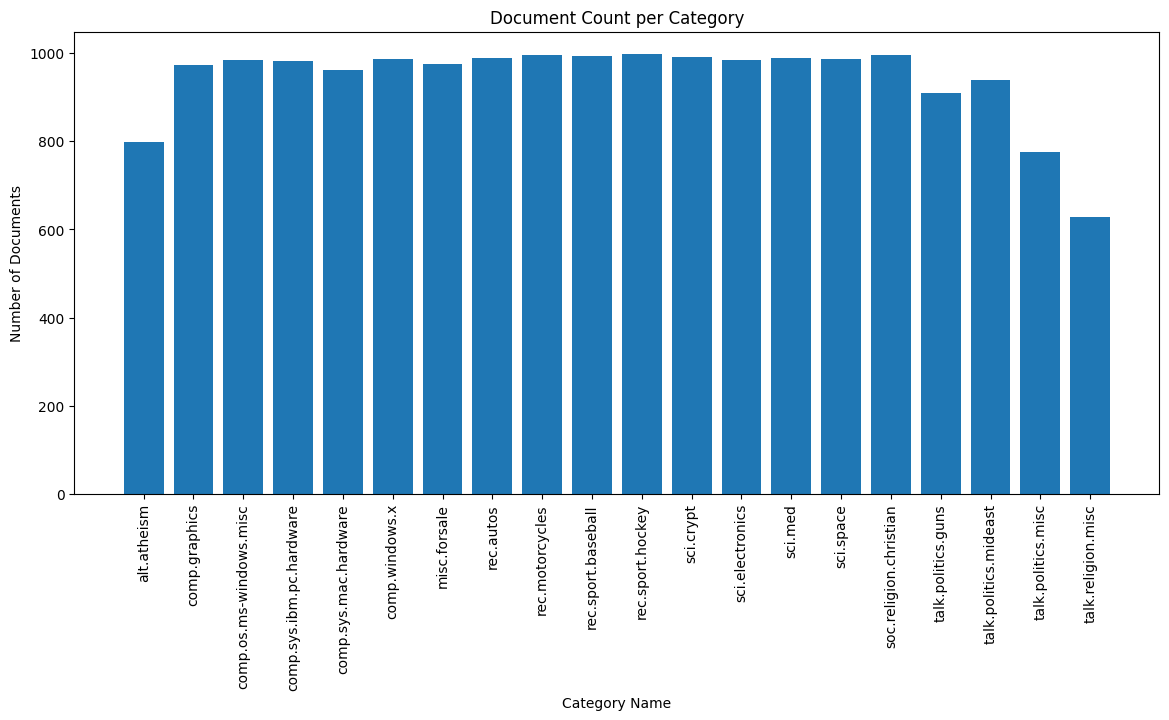

In [ ]:
category_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(14,6))

plt.bar(target_names, category_counts)

plt.title("Document Count per Category")

plt.xlabel("Category Name")

plt.ylabel("Number of Documents")

plt.xticks(rotation=90)

plt.show()

### 2.8 Most Frequent Words (Top Vocabulary Insight)

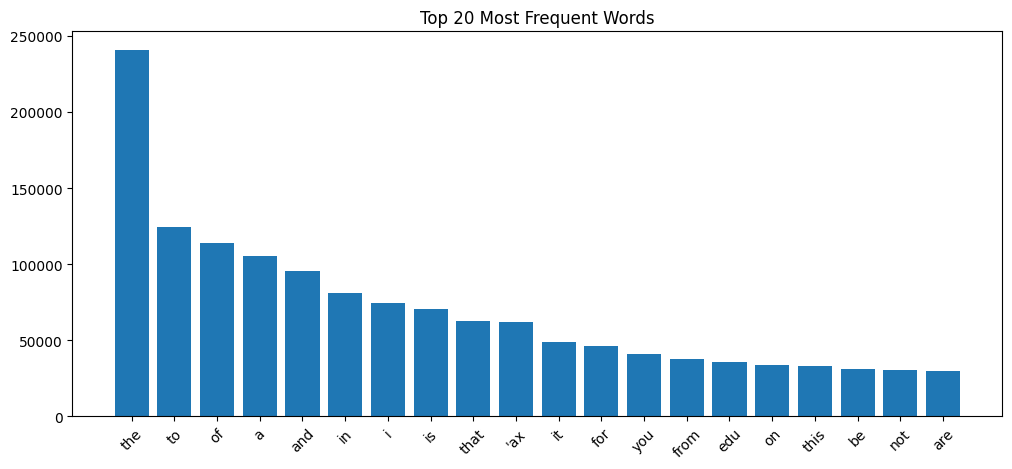

In [ ]:
word_counts = tokenizer.word_counts

# Convert dictionary to DataFrame
word_df = pd.DataFrame(
    list(word_counts.items()),
    columns=["Word","Count"]
)

top_words = word_df.sort_values(
    by="Count",
    ascending=False
).head(20)

plt.figure(figsize=(12,5))

plt.bar(top_words["Word"], top_words["Count"])

plt.title("Top 20 Most Frequent Words")

plt.xticks(rotation=45)

plt.show()

### 2.9 Display Sample Data

In [ ]:
for i in range(3):

    print("\nSample", i+1)
    print(texts[i][:500])
    print("Category:", target_names[labels[i]])


Sample 1
From: Mamatha Devineni Ratnam <mr47+@andrew.cmu.edu>
Subject: Pens fans reactions
Organization: Post Office, Carnegie Mellon, Pittsburgh, PA
Lines: 12
NNTP-Posting-Host: po4.andrew.cmu.edu



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killin
Category: rec.sport.hockey

Sample 2
From: mblawson@midway.ecn.uoknor.edu (Matthew B Lawson)
Subject: Which high-performance VLB video card?
Summary: Seek recommendations for VLB video card
Nntp-Posting-Host: midway.ecn.uoknor.edu
Organization: Engineering Computer Network, University of Oklahoma, Norman, OK, USA
Keywords: orchid, stealth, vlb
Lines: 21

  My brother is in the market for a high-performance video card that supports
VESA local bus with 1-2MB RAM.  Does anyone have sugge

## 3. Model Architecture
In this project, **Simple RNN and LSTM** models are implemented for **multi-class text classification** using the 20 Newsgroups dataset. Both models begin with an embedding layer that converts integer-encoded words into dense vector representations of fixed-length input sequences (400 words). In the **Simple RNN model**, the embedding dimension is set to **256**, followed by a **recurrent layer** with **128** units to learn sequential patterns from the text data. In the **LSTM model**, the embedding dimension is **128**, followed by an LSTM layer with **128** units that helps capture longer contextual dependencies more effectively. **Dropout and recurrent dropout (0.2)** are applied in both models to reduce overfitting. A final dense layer with **softmax activation** is used to classify the documents into 20 categories. The models are trained using the **Adam optimizer** with **categorical cross-entropy** loss, and **Early Stopping** is applied to improve training efficiency and model generalization.

### 3.1 Build Simple RNN Model

In [ ]:
def create_rnn_model():

    model = Sequential()

    model.add(Embedding(max_features, 256, input_length=maxlen))

    model.add(SimpleRNN(128,dropout=0.2,recurrent_dropout=0.2))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

### 3.2 Build LSTM Model

In [ ]:
def create_lstm_model():

    model = Sequential()

    model.add(Embedding(max_features, 128, input_length=maxlen))

    model.add(LSTM(128,dropout=0.2,recurrent_dropout=0.2))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

### 3.3 Create Models

In [ ]:
rnn_model = create_rnn_model()
lstm_model = create_lstm_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### 3.4 Early Stopping

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    verbose=1
)

### 3.5 Train Simple RNN

In [ ]:
print("Training RNN model...")

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Training RNN model...
Epoch 1/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.0856 - loss: 2.9966 - val_accuracy: 0.1679 - val_loss: 2.8819
Epoch 2/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.1871 - loss: 2.7779 - val_accuracy: 0.2939 - val_loss: 2.5809
Epoch 3/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.2939 - loss: 2.4955 - val_accuracy: 0.2973 - val_loss: 2.4972
Epoch 4/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.3751 - loss: 2.2293 - val_accuracy: 0.3682 - val_loss: 2.2582
Epoch 5/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.4325 - loss: 2.0428 - val_accuracy: 0.3743 - val_loss: 2.2393


### 3.6 Train LSTM

In [ ]:
print("Training LSTM model...")

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping]
)

Training LSTM model...
Epoch 1/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 624s 1s/step - accuracy: 0.2067 - loss: 2.5601 - val_accuracy: 0.3371 - val_loss: 2.1014
Epoch 2/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 618s 1s/step - accuracy: 0.4390 - loss: 1.7686 - val_accuracy: 0.4793 - val_loss: 1.6087
Epoch 3/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 620s 1s/step - accuracy: 0.5966 - loss: 1.2520 - val_accuracy: 0.5523 - val_loss: 1.3974
Epoch 4/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 620s 1s/step - accuracy: 0.7069 - loss: 0.9322 - val_accuracy: 0.6607 - val_loss: 1.1372
Epoch 5/5
472/472 ━━━━━━━━━━━━━━━━━━━━ 620s 1s/step - accuracy: 0.7770 - loss: 0.7245 - val_accuracy: 0.6416 - val_loss: 1.2218


### 3.7 Evaluate Models

In [ ]:
rnn_test_loss, rnn_test_accuracy = rnn_model.evaluate(X_test, y_test)

lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(X_test, y_test)

print(f"RNN Accuracy: {rnn_test_accuracy:.4f}")
print(f"LSTM Accuracy: {lstm_test_accuracy:.4f}")

print(f"RNN Loss: {rnn_test_loss:.4f}")
print(f"LSTM Loss: {lstm_test_loss:.4f}")

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3743 - loss: 2.2393
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 228ms/step - accuracy: 0.6416 - loss: 1.2218
RNN Accuracy: 0.3743
LSTM Accuracy: 0.6416
RNN Loss: 2.2393
LSTM Loss: 1.2218


### 3.8 Plot Accuracy Curves

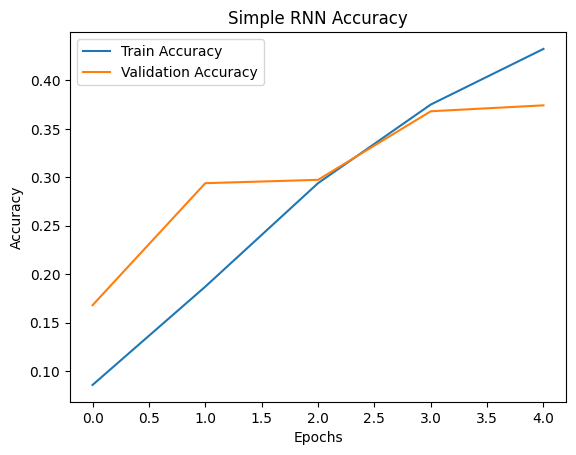

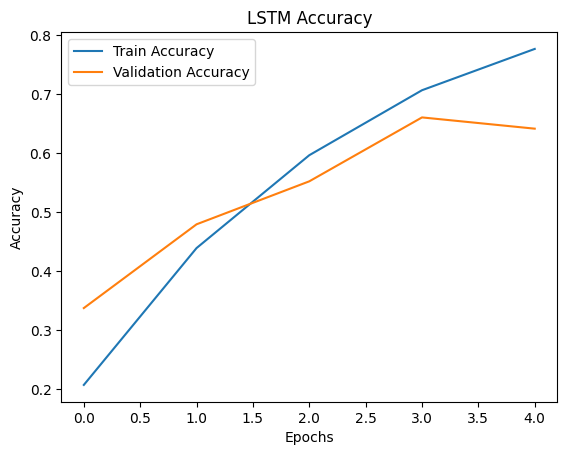

In [ ]:
def plot_history(history, model_name):

    plt.plot(history.history['accuracy'], label='Train Accuracy')

    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{model_name} Accuracy')

    plt.xlabel('Epochs')

    plt.ylabel('Accuracy')

    plt.legend()

    plt.show()


plot_history(rnn_history, 'Simple RNN')

plot_history(lstm_history, 'LSTM')

- In the Simple RNN accuracy curve, training accuracy increases steadily, but validation accuracy improves only up to a certain point and then fluctuates. This indicates that the model learns basic patterns from the data but has difficulty capturing long-term dependencies in longer text sequences and shows slight overfitting.

- In the LSTM accuracy curve shows steady improvement in both training and validation accuracy with a smaller gap between them. This suggests better learning and generalization performance. Overall, the LSTM model performs more effectively than the Simple RNN model for this text classification task.

### 3.9 Confusion Matrix

118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


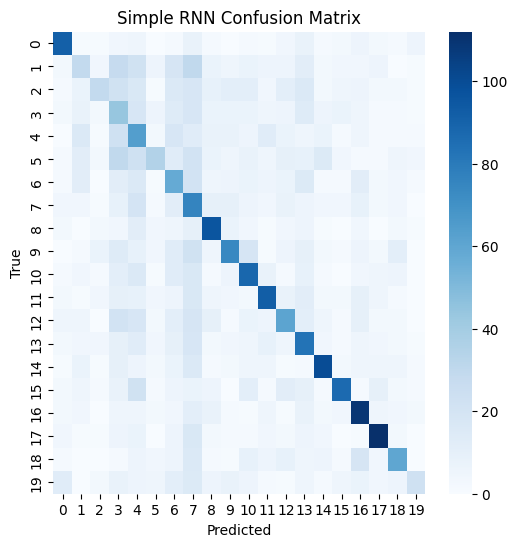

118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 232ms/step


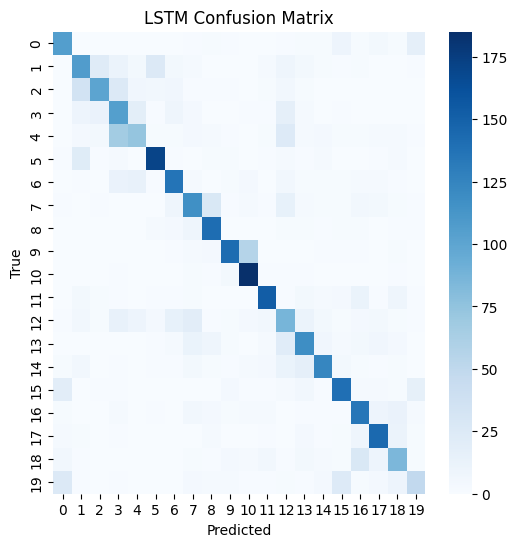

In [ ]:
def plot_confusion_matrix(model, X, y, model_name):

    predictions = np.argmax(model.predict(X), axis=1)

    true_labels = np.argmax(y, axis=1)

    cm = confusion_matrix(true_labels, predictions)

    plt.figure(figsize=(6,6))

    sns.heatmap(cm, annot=False, cmap='Blues')

    plt.title(f'{model_name} Confusion Matrix')

    plt.xlabel('Predicted')

    plt.ylabel('True')

    plt.show()


plot_confusion_matrix(rnn_model, X_test, y_test, "Simple RNN")

plot_confusion_matrix(lstm_model, X_test, y_test, "LSTM")

- From the Simple RNN confusion matrix, correct predictions are visible along the diagonal, but several off-diagonal values indicate misclassification between categories. This shows that the model learns general patterns but struggles to clearly distinguish some classes.

- In comparison, the LSTM confusion matrix has stronger diagonal values with fewer misclassifications. This indicates better class-wise prediction performance and improved ability to capture contextual information. Overall, the LSTM model performs better than the Simple RNN model for this classification task.

### 4 Prediction

In [ ]:
def show_predictions(model, X, y, model_name, num_examples=5):

    print(f"\nPredictions from {model_name}:\n")

    predictions = model.predict(X[:num_examples])

    for i in range(num_examples):

        predicted_label = np.argmax(predictions[i])

        true_label = np.argmax(y[i])

        print(f"\nExample {i+1}")

        print("True Label:", target_names[true_label])

        print("Predicted Label:", target_names[predicted_label])

        print("Confidence:", np.max(predictions[i]))


show_predictions(rnn_model, X_test, y_test, "Simple RNN")

show_predictions(lstm_model, X_test, y_test, "LSTM")


Predictions from Simple RNN:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step

Example 1
True Label: rec.sport.baseball
Predicted Label: misc.forsale
Confidence: 0.14021994

Example 2
True Label: sci.electronics
Predicted Label: sci.electronics
Confidence: 0.50770617

Example 3
True Label: sci.space
Predicted Label: comp.graphics
Confidence: 0.21312682

Example 4
True Label: talk.politics.misc
Predicted Label: comp.sys.mac.hardware
Confidence: 0.09925278

Example 5
True Label: alt.atheism
Predicted Label: sci.space
Confidence: 0.21694857

Predictions from LSTM:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step

Example 1
True Label: rec.sport.baseball
Predicted Label: rec.sport.hockey
Confidence: 0.6424554

Example 2
True Label: sci.electronics
Predicted Label: sci.electronics
Confidence: 0.9010226

Example 3
True Label: sci.space
Predicted Label: sci.med
Confidence: 0.63707584

Example 4
True Label: talk.politics.misc
Predicted Label: talk.politics.misc
Confidence: 0.4092982

Example 5
True Label: alt.

### 4.1 Final Comparison Table

In [ ]:
print("\nFinal Comparison")

print("Simple RNN Accuracy:", rnn_test_accuracy)

print("LSTM Accuracy:", lstm_test_accuracy)


Final Comparison
Simple RNN Accuracy: 0.37427055835723877
LSTM Accuracy: 0.6416445374488831


### Final Conclusion
- In this mini-project, Simple RNN and LSTM models were implemented on the 20 Newsgroups dataset to perform multi-class text classification. Both models successfully learned sequential representations from textual input using embedding layers and recurrent architectures.
- The results show that the LSTM model achieved better classification accuracy compared to the Simple RNN model due to its ability to preserve long-term contextual dependencies using memory gating mechanisms. Therefore, LSTM provides improved performance for complex sequence learning tasks compared to Simple RNN.